# LSTM Training - Anaerobic Digestion of Olive Mill Waste
### Crete Case Study

---

## results from RNN testing and why try LSTM

RNN testing results:

**RNN online framework results:**

| run | MAPE S | MAPE M | MAPE pH |
|-----|--------|--------|---------|
| T=30 S0=15 OLR=1 (low temp, low substrate) | 0.47% | 1.81% | 0.01% |
| T=35 S0=35 OLR=3 (optimal conditions) | 0.33% | 2.31% | 0.04% |
| T=42 S0=55 OLR=6 (high temp, high substrate) | 0.17% | 2.14% | 0.10% |
| T=30 S0=55 OLR=6 (low temp, high substrate) | 1.25% | 4.78% | 0.07% |
| **Mean** | **0.56%** | **2.76%** | **0.06%** |

**RNN offline framework results:**

| run | MAPE S | MAPE M | MAPE pH |
|-----|--------|--------|---------|
| T=30 S0=15 OLR=1 | 13.67% | 8.80% | 0.09% |
| T=35 S0=35 OLR=3 | 9.81% | 13.38% | 0.78% |
| T=42 S0=55 OLR=6 | 2.96% | 10.91% | 2.23% |
| T=30 S0=55 OLR=6 | 69.62% | 35.66% | 0.97% |
| **Mean** | **24.02%** | **17.19%** | **1.02%** |

**direct comparison against ANN offline results:**

| variable | ANN Mean | RNN Mean | best |
|----------|----------|----------|--------|
| S (g VS/L/day) | 0.45% | 24.02% | ANN by a large margin |
| M (mL/L/day) | 0.29% | 17.19% | ANN by a large margin |
| pH (pH/day) | 0.02% | 1.02% | ANN by a large margin |

**Interpretation:**

Despite achieving a training loss 11 times lower than the ANN (0.000138 vs
0.001549), the RNN performs much worse in the offline testing framework
where it matters most. the low temp, high substrate run produced an offline MAPE
of 69.62% for volatile solids, which is very much outside acceptable limits for a surrogate
model

the cause could be exposure bias combined with error accumulation. the RNN was trained
on sequences of real measured states. during offline testing, the sequence window
is built from predicted states. any small error in an early prediction "contaminates"
the entire window, which degrades the next prediction, which degrades the next window
etc. because the RNN has memory of previous steps, errors compound across the
entire 30-day simulation in a way that does not occur for the ANN, which treats
each timestep independently

this is a documented limitation of recurrent models in autoregressive
simulation settings, a lower training loss does not guarantee better practical
performance

**why LSTM may perform better:**

the LSTM (Long Short-Term Memory) addresses a weakness of the basic RNN
through its gating mechanism. it has 3 gates: input gate, forget gate and
output gate. 

the forget gate: allows the model to selectively discard irrelevant
historical information and focus on what is currently useful and this makes the LSTM
more selective about what history it carries forward, which may reduce the impact
of corrupted states in the offline sequence window compared to the standard RNN

the LSTM also avoids the vanishing gradient problem that affects basic RNNs during
training, which means it can learn longer range dependencies more reliably. whether
this translates to better offline performance on this specific problem is the
question this notebook is trying to answer

---

## architecture

the LSTM follows the same structure as the RNN with one difference: the RNN
cell is replaced by an LSTM cell. The LSTM maintains both a hidden state and a
cell state, where the cell state acts as the long-term memory and the hidden state
acts as the short-term output

input sequence (seq_len=12, features=5) → LSTM layer → linear readout from
final hidden state → 3 output rates (dS/dt, dM/dt, dpH/dt)


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch version: 2.11.0
cuda available: False


## 2. Load Data

In [2]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

print(f"reference data: {len(data_ref)} rows")

reference data: 1080 rows


## 3. Standardise

In [3]:
scaler = StandardScaler()
scaler.fit(data_ref)

std_ref = scaler.transform(data_ref)
x_ref   = std_ref[:, 0:5]
y_ref   = std_ref[:, 5:8]

print("scaler fitted")
print("means: ", [round(m, 3) for m in scaler.mean_])
print("stds:  ", [round(s, 3) for s in scaler.scale_])

scaler fitted
means:  [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]
stds:   [np.float64(12.582), np.float64(4702.294), np.float64(0.156), np.float64(4.38), np.float64(2.055), np.float64(0.754), np.float64(286.686), np.float64(0.016)]


## 4. Create Sequences and Augment

In [4]:
seq_len      = 12
n_runs       = 36
rows_per_run = 30

sequences_x = []
sequences_y = []

for run_i in range(n_runs):
    start = run_i * rows_per_run
    end   = start + rows_per_run
    run_x = x_ref[start:end]
    run_y = y_ref[start:end]
    for t in range(rows_per_run - seq_len):
        sequences_x.append(run_x[t : t + seq_len])
        sequences_y.append(run_y[t + seq_len - 1])

sequences_x = np.array(sequences_x)
sequences_y = np.array(sequences_y)

print(f"clean sequences: {sequences_x.shape}")

NOISE_LEVEL  = 0.05 * 0.333
REPLICATIONS = 25

aug_x = []
aug_y = []

for i in range(len(sequences_x)):
    base_x = sequences_x[i]
    base_y = sequences_y[i]
    for _ in range(REPLICATIONS):
        noisy_x = np.random.normal(base_x, np.abs(base_x) * NOISE_LEVEL + 1e-6)
        noisy_y = np.random.normal(base_y, np.abs(base_y) * NOISE_LEVEL + 1e-6)
        aug_x.append(noisy_x)
        aug_y.append(noisy_y)

aug_x = np.array(aug_x)
aug_y = np.array(aug_y)

idx   = np.random.permutation(len(aug_x))
aug_x = aug_x[idx]
aug_y = aug_y[idx]

x_train = torch.tensor(aug_x, dtype=torch.float32)
y_train = torch.tensor(aug_y, dtype=torch.float32)

print(f"augmented sequences: {x_train.shape}")
print(f"augmented targets  : {y_train.shape}")

clean sequences: (648, 12, 5)
augmented sequences: torch.Size([16200, 12, 5])
augmented targets  : torch.Size([16200, 3])


## 5. Define the LSTM Model

key difference from RNN: `nn.LSTM` instead of `nn.RNN`.
the LSTM forward pass returns both hidden state (hn) and cell state (cn)
only the hidden state is used for the linear readout which is the same as the RNN


In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # initialise hidden state and cell state with zeros
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)

        # pass sequence through LSTM
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        # readout from final hidden state
        out = self.fc(out[:, -1, :])
        return out

# starting hyperparameters: rough values, K-Fold will tune
input_dim    = 5
hidden_dim   = 20
layer_dim    = 2      # 2 layers: standard for LSTM (original dissertation used 2)
output_dim   = 3
N            = 50
train_epochs = 200
learning_rate= 1e-3

model   = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
loss_fn = nn.MSELoss(reduction='mean')

print("LSTM model:")
print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params}")
print()
test = model(x_train[:N])
print(f"forward pass OK — output shape: {test.shape}")

LSTM model:
LSTMModel(
  (lstm): LSTM(5, 20, num_layers=2, batch_first=True)
  (fc): Linear(in_features=20, out_features=3, bias=True)
)

total parameters: 5583

forward pass OK — output shape: torch.Size([50, 3])


## 6. DataLoader

In [6]:
dataset    = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=N, shuffle=True)

print(f"dataset size  : {len(dataset)} sequences")
print(f"batch size    : {N}")
print(f"batches/epoch : {len(dataloader)}")

dataset size  : 16200 sequences
batch size    : 50
batches/epoch : 324


## 7. Train

In [7]:
optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

model.train()
print(f"training: {train_epochs} epochs, lr={learning_rate}, batch={N}")
print("-" * 55)

for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / len(dataloader)
    loss_history.append(epoch_loss)
    if epoch % 20 == 0 or epoch == train_epochs - 1:
        print(f"epoch {epoch:>4d}   loss = {epoch_loss:.6f}")

print("-" * 55)
print(f"done. final loss     : {loss_history[-1]:.6f}")
print(f"RNN first run loss   : 0.000138")
print(f"ANN retrained loss   : 0.001549")

training: 200 epochs, lr=0.001, batch=50
-------------------------------------------------------
epoch    0   loss = 0.043078
epoch   20   loss = 0.000147
epoch   40   loss = 0.000138
epoch   60   loss = 0.000136
epoch   80   loss = 0.000127
epoch  100   loss = 0.000130
epoch  120   loss = 0.000122
epoch  140   loss = 0.000122
epoch  160   loss = 0.000118
epoch  180   loss = 0.000121
epoch  199   loss = 0.000119
-------------------------------------------------------
done. final loss     : 0.000119
RNN first run loss   : 0.000138
ANN retrained loss   : 0.001549


## 8. Loss Curve

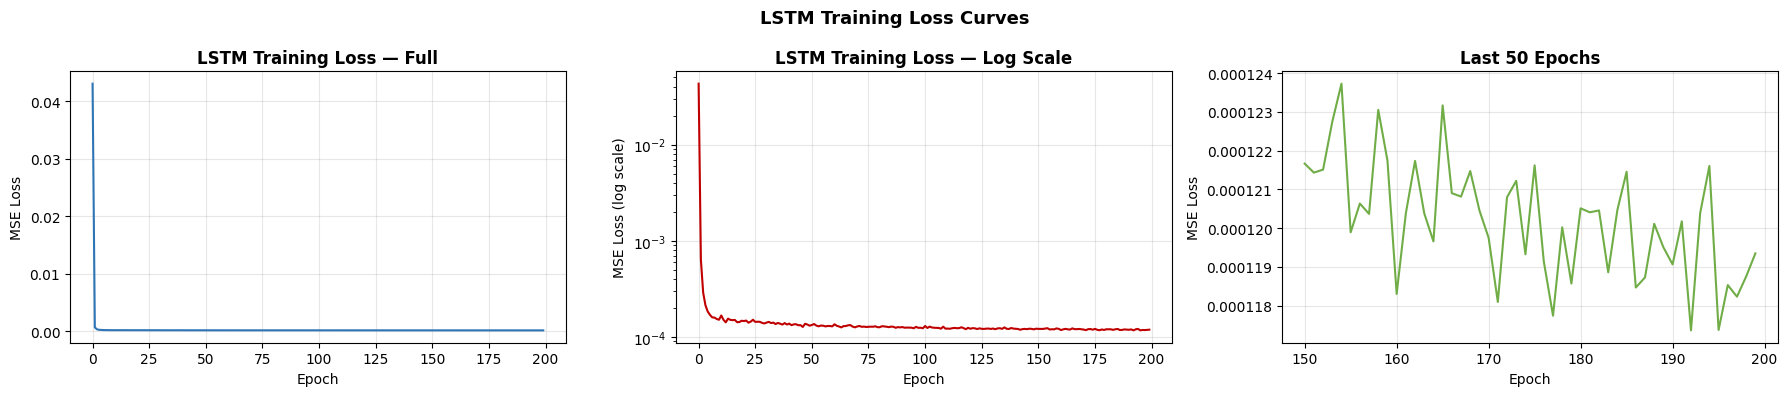

starting loss : 0.043078
final loss    : 0.000119
reduction     : 99.7%
last 50 drop  : 0.0000023
CONVERGED


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('LSTM Training Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('LSTM Training Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(train_epochs-50, train_epochs),
             loss_history[-50:], color='#70AD47', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Last 50 Epochs', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('LSTM Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

last50_drop = loss_history[-50] - loss_history[-1]
print(f"starting loss : {loss_history[0]:.6f}")
print(f"final loss    : {loss_history[-1]:.6f}")
print(f"reduction     : {((loss_history[0]-loss_history[-1])/loss_history[0])*100:.1f}%")
print(f"last 50 drop  : {last50_drop:.7f}")
if last50_drop < 0.00005:
    print("CONVERGED")
elif last50_drop < 0.0002:
    print("nearly converged")
else:
    print("still decreasing — K-Fold will tune further")

## 9. Predicted vs Actual

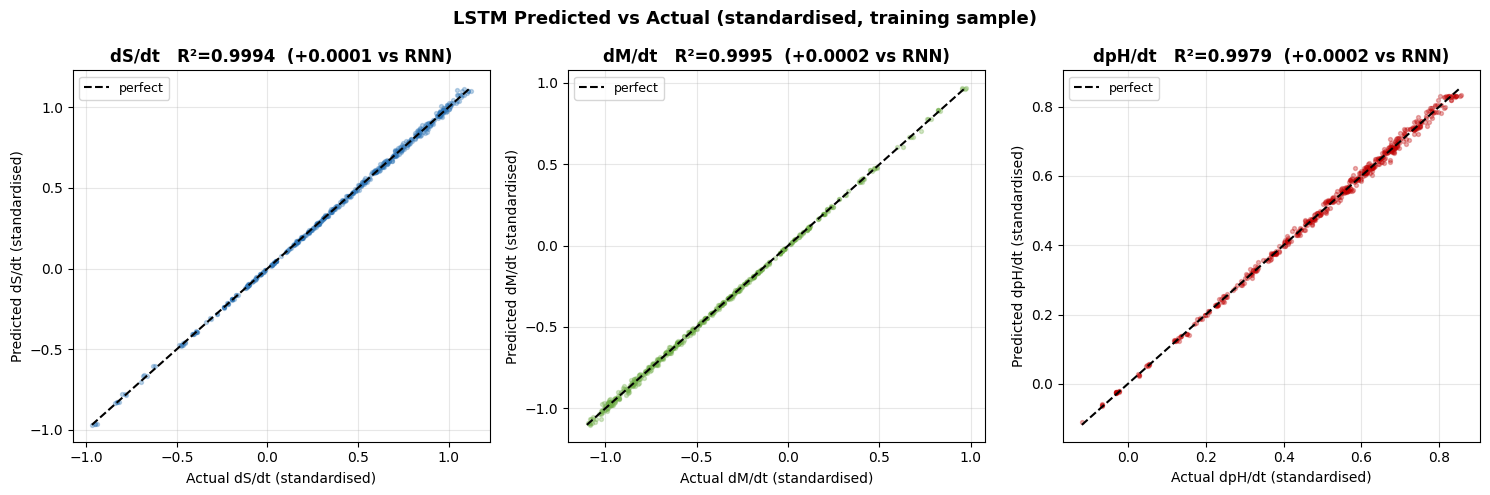

R² comparison:
                    RNN       LSTM     Change
-------------------------------------------
  dS/dt          0.9993     0.9994    +0.0001
  dM/dt          0.9993     0.9995    +0.0002
  dpH/dt         0.9977     0.9979    +0.0002


In [9]:
model.eval()
with torch.no_grad():
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names = ['dS/dt', 'dM/dt', 'dpH/dt']
colors = ['#2E75B6', '#70AD47', '#C00000']
rnn_r2 = [0.9993, 0.9993, 0.9977]

r2_vals = []
for i, (ax, name, col, rr2) in enumerate(
        zip(axes, target_names, colors, rnn_r2)):
    ax.scatter(actual_np[:, i], preds_np[:, i],
               alpha=0.3, s=8, color=col)
    lims = [min(actual_np[:,i].min(), preds_np[:,i].min()),
            max(actual_np[:,i].max(), preds_np[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2     = 1 - ss_res / ss_tot
    r2_vals.append(r2)
    delta  = r2 - rr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}   R²={r2:.4f}  ({delta_str} vs RNN)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM Predicted vs Actual (standardised, training sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("R² comparison:")
print(f"{'':12} {'RNN':>10} {'LSTM':>10} {'Change':>10}")
print("-" * 43)
for name, r2, rr2 in zip(target_names, r2_vals, rnn_r2):
    delta     = r2 - rr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    print(f"  {name:<10} {rr2:>10.4f} {r2:>10.4f} {delta_str:>10}")

## 10. Residual Analysis

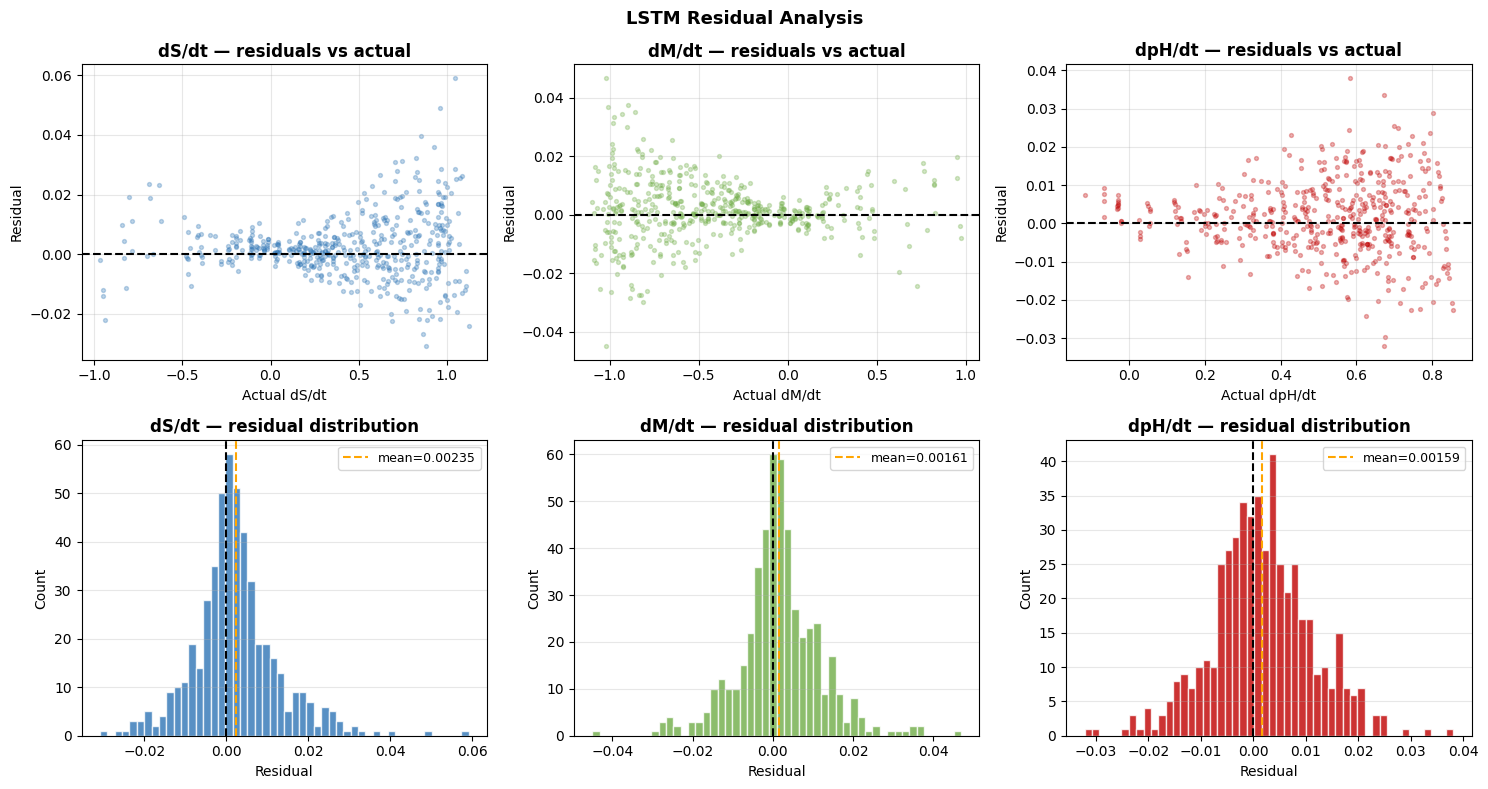

residual means (should be close to 0):
  dS/dt: 0.002350
  dM/dt: 0.001614
  dpH/dt: 0.001590


In [10]:
residuals = preds_np - actual_np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, col) in enumerate(zip(target_names, colors)):
    axes[0, i].scatter(actual_np[:, i], residuals[:, i],
                       alpha=0.3, s=8, color=col)
    axes[0, i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0, i].set_xlabel(f'Actual {name}')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].set_title(f'{name} — residuals vs actual', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(residuals[:, i], bins=50, color=col,
                    alpha=0.8, edgecolor='white')
    axes[1, i].axvline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1, i].axvline(residuals[:, i].mean(), color='orange',
                       linewidth=1.5, linestyle='--',
                       label=f'mean={residuals[:,i].mean():.5f}')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} — residual distribution', fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('LSTM Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("residual means (should be close to 0):")
for i, name in enumerate(target_names):
    print(f"  {name}: {residuals[:,i].mean():.6f}")

## 11. Save Model

In [11]:
torch.save(model.state_dict(), 'LSTM_olive_mill.pt')
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

print("saved: LSTM_olive_mill.pt")
print()
print("to reload:")
print(f"  model = LSTMModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print("  model.load_state_dict(torch.load('LSTM_olive_mill.pt'))")
print("  model.eval()")
print()
print("next step: LSTM_KFold_Olive_Mill.ipynb")

saved: LSTM_olive_mill.pt

to reload:
  model = LSTMModel(5, 20, 2, 3)
  model.load_state_dict(torch.load('LSTM_olive_mill.pt'))
  model.eval()

next step: LSTM_KFold_Olive_Mill.ipynb


## 12. Summary

In [12]:
print("=" * 58)
print("LSTM TRAINING SUMMARY (first run)")
print("=" * 58)
print(f"  architecture  : LSTMModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print(f"  parameters    : {sum(p.numel() for p in model.parameters())}")
print(f"  sequence len  : {seq_len}")
print(f"  training seqs : {len(x_train)}")
print(f"  epochs        : {train_epochs}")
print(f"  learning rate : {learning_rate}")
print(f"  batch size    : {N}")
print(f"  final MSE loss: {loss_history[-1]:.6f}")
print(f"  RNN loss      : 0.000138")
print(f"  ANN loss      : 0.001549")
print("=" * 58)
print()


LSTM TRAINING SUMMARY (first run)
  architecture  : LSTMModel(5, 20, 2, 3)
  parameters    : 5583
  sequence len  : 12
  training seqs : 16200
  epochs        : 200
  learning rate : 0.001
  batch size    : 50
  final MSE loss: 0.000119
  RNN loss      : 0.000138
  ANN loss      : 0.001549

